# Fuzzy Tsukamoto — Contractor Fuel Ratio Risk

Notebook ini menerapkan **Fuzzy Tsukamoto** untuk menghasilkan satu `risk_score` crisp per contractor. Input mencakup produktivitas Loading, populasi Support + Dewatering, dan deviasi fuel aktual terhadap Kideco site reference.

Output Tsukamoto menggunakan consequent monoton: `RISK_LOW` dan `RISK_HIGH`. Nilai aktual diambil dari summary operasional jika tersedia; data demo diberi sumber `OPERATIONAL_ACTUAL` oleh seeder.

In [31]:
from pathlib import Path
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

candidates = [Path.cwd() / 'frms.db', Path.cwd() / 'backend' / 'frms.db']
if '__file__' in globals():
    candidates.insert(0, Path(__file__).resolve().parent / 'frms.db')
db_path = next((p.resolve() for p in candidates if p.exists() and p.stat().st_size > 0), None)
if db_path is None:
    raise FileNotFoundError('frms.db tidak ditemukan.')
print(f'✅ Database: {db_path}')

✅ Database: /Users/rifkinasss/Documents/workspace/Lomba/KIC 2026/Code Base/backend/frms.db


## 1. Agregasi Data Contractor

Fuel actual dihitung sebagai `fuel_consumed_liters / operating_hours`. Untuk Support/Dewatering, summary memakai `fuel_cons_lhr`. Jika actual belum tersedia, reference digunakan sebagai fallback dan ditandai.

In [32]:
conn = sqlite3.connect(db_path)
loading = pd.read_sql_query('''
    SELECT e.contractor_id, c.company_name AS contractor, e.qty, e.productivity,
           COALESCE(ls.fuel_cons_actual, ls.fuel_cons_reference, e.qty * fr.average) AS fuel_cons_lhr,
           COALESCE(ls.fuel_cons_reference, e.qty * fr.average) AS fuel_cons_reference,
           COALESCE(ls.data_source, 'OEM_REFERENCE') AS data_source
    FROM equipment e
    JOIN contractor c ON c.id = e.contractor_id
    LEFT JOIN loading l ON l.id = (
        SELECT l2.id FROM loading l2 WHERE l2.equipment_id = e.id
        ORDER BY l2.created_at DESC, l2.id DESC LIMIT 1
    )
    LEFT JOIN fuel_reference fr ON fr.id = l.fuel_reference_id
    LEFT JOIN loading_summary ls ON ls.loading_id = l.id
    WHERE UPPER(e.activity) = 'LOADING' AND e.productivity > 0
''', conn)
support_dew = pd.read_sql_query('''
    SELECT e.contractor_id, c.company_name AS contractor, e.qty,
           CASE WHEN UPPER(e.activity) = 'SUPPORTING' THEN COALESCE(ss.fuel_cons_lhr, e.qty * fr.average)
                WHEN UPPER(e.activity) = 'DEWATERING' THEN COALESCE(ds.fuel_cons_lhr, e.qty * fr.average)
                ELSE 0 END AS fuel_cons_lhr,
           e.qty * fr.average AS fuel_cons_reference,
           UPPER(e.activity) AS activity
    FROM equipment e
    JOIN contractor c ON c.id = e.contractor_id
    LEFT JOIN fuel_reference fr ON fr.id = COALESCE((SELECT s.fuel_reference_id FROM supporting s WHERE s.equipment_id=e.id ORDER BY s.id DESC LIMIT 1), (SELECT d.fuel_reference_id FROM dewatering d WHERE d.equipment_id=e.id ORDER BY d.id DESC LIMIT 1))
    LEFT JOIN supporting s ON s.id = (SELECT s2.id FROM supporting s2 WHERE s2.equipment_id=e.id ORDER BY s2.id DESC LIMIT 1)
    LEFT JOIN supporting_summary ss ON ss.supporting_id = s.id
    LEFT JOIN dewatering d ON d.id = (SELECT d2.id FROM dewatering d2 WHERE d2.equipment_id=e.id ORDER BY d2.id DESC LIMIT 1)
    LEFT JOIN dewatering_summary ds ON ds.dewatering_id = d.id
    WHERE UPPER(e.activity) IN ('SUPPORTING', 'DEWATERING')
''', conn)
conn.close()

if loading.empty:
    raise ValueError('Data Loading kosong.')

loading_g = loading.groupby(['contractor_id', 'contractor'], as_index=False).agg(
    loading_population=('qty', 'sum'),
    loading_productivity=('productivity', lambda x: np.average(x, weights=loading.loc[x.index, 'qty'])),
    loading_fuel_actual=('fuel_cons_lhr', 'sum'),
    loading_fuel_reference=('fuel_cons_reference', 'sum'),
)
support_dew_g = support_dew.groupby(['contractor_id', 'contractor'], as_index=False).agg(
    support_dew_population=('qty', 'sum'),
    support_dew_fuel=('fuel_cons_lhr', 'sum'),
    support_dew_fuel_reference=('fuel_cons_reference', 'sum'),
)
df = loading_g.merge(support_dew_g, on=['contractor_id', 'contractor'], how='left').fillna(0)
df['total_fuel_actual'] = df['loading_fuel_actual'] + df['support_dew_fuel']
df['total_fuel_reference'] = df['loading_fuel_reference'] + df['support_dew_fuel_reference']
df['fuel_deviation_ratio'] = np.where(df['total_fuel_reference'] > 0, df['total_fuel_actual'] / df['total_fuel_reference'], 1.0)
df['support_dew_fuel_share_pct'] = np.where(df['total_fuel_actual'] > 0, df['support_dew_fuel'] / df['total_fuel_actual'] * 100, 0)
print(df.to_string(index=False))

 contractor_id contractor  loading_population  loading_productivity  loading_fuel_actual  loading_fuel_reference  support_dew_population  support_dew_fuel  support_dew_fuel_reference  total_fuel_actual  total_fuel_reference  fuel_deviation_ratio  support_dew_fuel_share_pct
             1      PT. A                  64            487.306250              5559.48                  5470.0                      94            1050.0                      1050.0            6609.48                6520.0              1.013724                   15.886272
             2      PT. B                  68            526.811765              5788.26                  5653.0                      14             474.0                       474.0            6262.26                6127.0              1.022076                    7.569152
             3      PT. C                  42            578.438095              3771.04                  3958.0                      22             172.0                       1

## 2. Membership Input

Produktivitas dan populasi menggunakan kuartil antar-contractor. Fuel deviation memakai baseline 0.90–1.00–1.10 terhadap reference; nilai di atas 1.10 mulai dianggap `UP`.

In [33]:
def trimf(x, a, b, c):
    if x <= a or x >= c: return 0.0
    if x == b: return 1.0
    return (x - a) / (b - a) if x < b else (c - x) / (c - b)

def left_shoulder(x, a, b):
    return 1.0 if x <= a else 0.0 if x >= b else (b - x) / (b - a)

def right_shoulder(x, a, b):
    return 0.0 if x <= a else 1.0 if x >= b else (x - a) / (b - a)

prod_q25, prod_q50, prod_q75 = df['loading_productivity'].quantile([.25, .50, .75])
pop_q25, pop_q50, pop_q75 = df['support_dew_population'].quantile([.25, .50, .75])
def three_sets(x, q25, q50, q75):
    return {'DOWN': left_shoulder(x, q25, q50), 'NORMAL': trimf(x, q25, q50, q75), 'UP': right_shoulder(x, q50, q75)}

df['mu_prod'] = df['loading_productivity'].apply(lambda x: three_sets(x, prod_q25, prod_q50, prod_q75))
df['mu_population'] = df['support_dew_population'].apply(lambda x: three_sets(x, pop_q25, pop_q50, pop_q75))
df['mu_fuel'] = df['fuel_deviation_ratio'].apply(lambda x: {'DOWN': left_shoulder(x, .90, 1.00), 'NORMAL': trimf(x, .90, 1.00, 1.10), 'UP': right_shoulder(x, 1.00, 1.10)})
print(f'Productivity quartiles: {prod_q25:.1f}, {prod_q50:.1f}, {prod_q75:.1f}')
print(f'Support/Dewatering population quartiles: {pop_q25:.1f}, {pop_q50:.1f}, {pop_q75:.1f}')
membership_view = pd.DataFrame({
    'contractor': df['contractor'],
    'productivity_DOWN': df['mu_prod'].apply(lambda m: m['DOWN']),
    'productivity_NORMAL': df['mu_prod'].apply(lambda m: m['NORMAL']),
    'productivity_UP': df['mu_prod'].apply(lambda m: m['UP']),
    'population_DOWN': df['mu_population'].apply(lambda m: m['DOWN']),
    'population_NORMAL': df['mu_population'].apply(lambda m: m['NORMAL']),
    'population_UP': df['mu_population'].apply(lambda m: m['UP']),
    'fuel_DOWN': df['mu_fuel'].apply(lambda m: m['DOWN']),
    'fuel_NORMAL': df['mu_fuel'].apply(lambda m: m['NORMAL']),
    'fuel_UP': df['mu_fuel'].apply(lambda m: m['UP']),
})
print('Derajat keanggotaan (μ) setiap input:')
print(membership_view.round(4).to_string(index=False))


Productivity quartiles: 488.8, 536.3, 561.0
Support/Dewatering population quartiles: 27.8, 35.5, 56.8
Derajat keanggotaan (μ) setiap input:
contractor  productivity_DOWN  productivity_NORMAL  productivity_UP  population_DOWN  population_NORMAL  population_UP  fuel_DOWN  fuel_NORMAL  fuel_UP
     PT. A             1.0000               0.0000           0.0000           0.0000             0.0000         1.0000     0.0000       0.8628   0.1372
     PT. B             0.1993               0.8007           0.0000           1.0000             0.0000         0.0000     0.0000       0.7792   0.2208
     PT. C             0.0000               0.0000           1.0000           1.0000             0.0000         0.0000     0.4527       0.5473   0.0000
     PT. D             0.0000               0.0000           1.0000           0.1935             0.8065         0.0000     0.0000       0.0000   1.0000
     PT. E             0.9053               0.0947           0.0000           0.0000             0.0

## 3. Tsukamoto Rule Base

Consequent Tsukamoto harus monoton. `RISK_LOW` memakai fungsi menurun sehingga z = 1 − α, sedangkan `RISK_HIGH` memakai fungsi meningkat sehingga z = α.

In [34]:
def tsukamoto_score(row):
    p, q, f = row['mu_prod'], row['mu_population'], row['mu_fuel']
    rules = [
        ('R1_productivity_down', p['DOWN'], 'HIGH'),
        ('R2_support_dew_population_up', q['UP'], 'HIGH'),
        ('R3_fuel_deviation_up', f['UP'], 'HIGH'),
        ('R4_productivity_down_and_population_up', min(p['DOWN'], q['UP']), 'HIGH'),
        ('R5_all_normal', min(p['NORMAL'], q['NORMAL'], f['NORMAL']), 'LOW'),
        ('R6_productive_and_fuel_normal', min(p['UP'], f['NORMAL']), 'LOW'),
    ]
    weighted_sum = 0.0
    alpha_sum = 0.0
    fired = {}
    for name, alpha, consequent in rules:
        if alpha <= 0: continue
        z = alpha if consequent == 'HIGH' else 1.0 - alpha
        weighted_sum += alpha * z
        alpha_sum += alpha
        fired[name] = round(alpha, 4)
    if alpha_sum == 0:
        return pd.Series({'risk_score': 0.5, 'dominant_rules': 'NO_RULE_FIRED'})
    score = weighted_sum / alpha_sum
    dominant = ', '.join(name for name, alpha in sorted(fired.items(), key=lambda item: item[1], reverse=True)[:3])
    return pd.Series({'risk_score': round(score, 4), 'dominant_rules': dominant})

df[['risk_score', 'dominant_rules']] = df.apply(tsukamoto_score, axis=1)
df['risk_status'] = pd.cut(df['risk_score'], [-np.inf, .35, .65, np.inf], labels=['LOW', 'MEDIUM', 'HIGH'])
output_cols = ['contractor', 'loading_productivity', 'support_dew_population', 'fuel_deviation_ratio', 'support_dew_fuel_share_pct', 'risk_score', 'risk_status', 'dominant_rules']
print(df[output_cols].sort_values('risk_score', ascending=False).to_string(index=False))

contractor  loading_productivity  support_dew_population  fuel_deviation_ratio  support_dew_fuel_share_pct  risk_score risk_status                                                                             dominant_rules
     PT. D            715.776744                      34              1.105674                   13.025738      1.0000        HIGH                                                                       R3_fuel_deviation_up
     PT. A            487.306250                      94              1.013724                   15.886272      0.9623        HIGH R1_productivity_down, R2_support_dew_population_up, R4_productivity_down_and_population_up
     PT. E            493.300000                      57              0.964072                   31.706848      0.9390        HIGH R2_support_dew_population_up, R1_productivity_down, R4_productivity_down_and_population_up
     PT. I            477.763636                      30              1.007985                    2.062891      

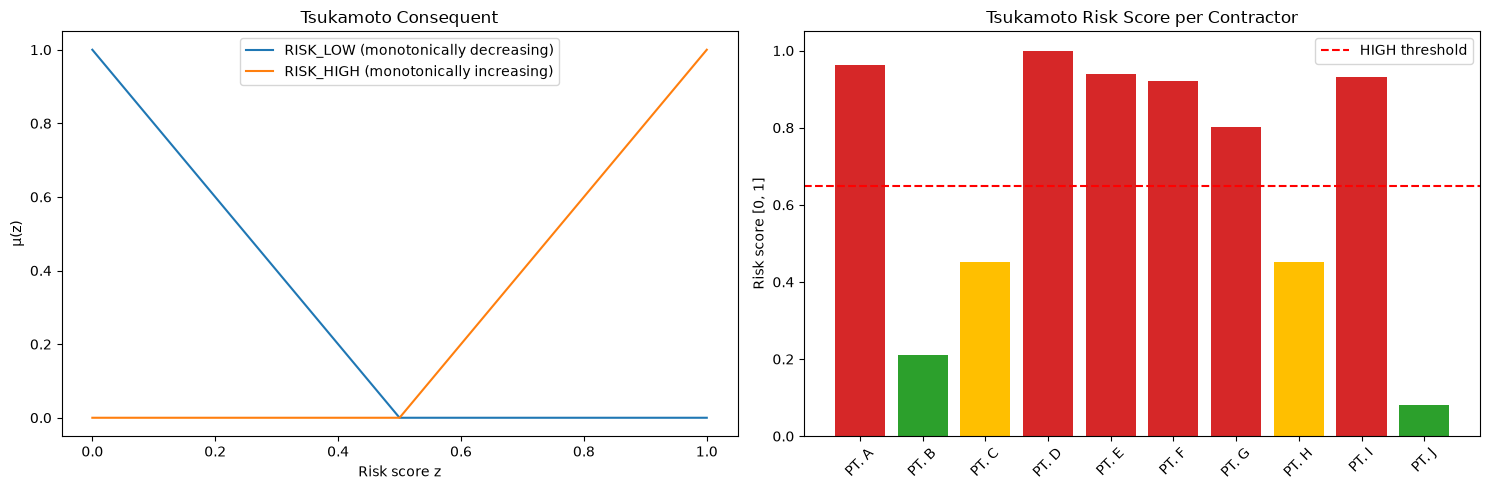

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.linspace(0, 1, 501)
axes[0].plot(x, [left_shoulder(v, 0, .5) for v in x], label='RISK_LOW (monotonically decreasing)')
axes[0].plot(x, [right_shoulder(v, .5, 1) for v in x], label='RISK_HIGH (monotonically increasing)')
axes[0].set_title('Tsukamoto Consequent')
axes[0].set_xlabel('Risk score z')
axes[0].set_ylabel('μ(z)')
axes[0].legend()
axes[1].bar(df['contractor'], df['risk_score'], color=['#d62728' if x >= .65 else '#ffbf00' if x >= .35 else '#2ca02c' for x in df['risk_score']])
axes[1].axhline(.65, color='red', linestyle='--', label='HIGH threshold')
axes[1].set_title('Tsukamoto Risk Score per Contractor')
axes[1].set_ylabel('Risk score [0, 1]')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
fig.tight_layout()
plt.show()

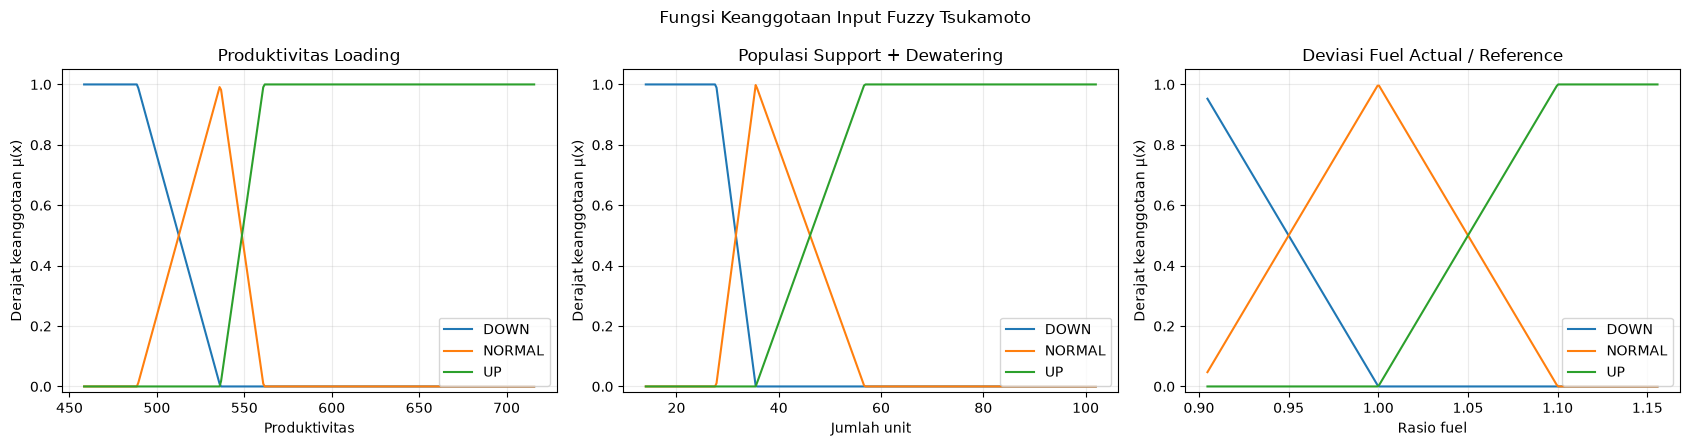

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
prod_x = np.linspace(df['loading_productivity'].min(), df['loading_productivity'].max(), 300)
pop_x = np.linspace(df['support_dew_population'].min(), df['support_dew_population'].max(), 300)
fuel_x = np.linspace(max(0, df['fuel_deviation_ratio'].min() - .05), df['fuel_deviation_ratio'].max() + .05, 300)
for label in ['DOWN', 'NORMAL', 'UP']:
    axes[0].plot(prod_x, [three_sets(x, prod_q25, prod_q50, prod_q75)[label] for x in prod_x], label=label)
    axes[1].plot(pop_x, [three_sets(x, pop_q25, pop_q50, pop_q75)[label] for x in pop_x], label=label)
fuel_sets = {'DOWN': lambda x: left_shoulder(x, .90, 1.00), 'NORMAL': lambda x: trimf(x, .90, 1.00, 1.10), 'UP': lambda x: right_shoulder(x, 1.00, 1.10)}
for label, fn in fuel_sets.items():
    axes[2].plot(fuel_x, [fn(x) for x in fuel_x], label=label)
titles = ['Produktivitas Loading', 'Populasi Support + Dewatering', 'Deviasi Fuel Actual / Reference']
labels = ['Produktivitas', 'Jumlah unit', 'Rasio fuel']
for ax, title, xlabel in zip(axes, titles, labels):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Derajat keanggotaan μ(x)')
    ax.set_ylim(-.02, 1.05)
    ax.grid(alpha=.25)
    ax.legend()
fig.suptitle('Fungsi Keanggotaan Input Fuzzy Tsukamoto')
fig.tight_layout()
plt.show()


## Interpretasi

`risk_score` adalah skor prioritas monitoring, bukan bukti klaim atau kesalahan kontraktor. `dominant_rules` menjelaskan pemicu terbesar: produktivitas Loading rendah, populasi Support/Dewatering tinggi, atau deviasi fuel actual terhadap reference.